# No Flux in 2D Domain (Disk)

## Setup

### Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import sys
sys.path.append("..")

### Import custom functions

In [3]:
from sources.simulation import *
from sources.plotting import *
from sources.analysis import *
from sources.models import *
from sources.data_storage import *

### Parameters

In [4]:

radius = 1.0
bins = 75
theta_bins = 40
r_bins = 10
boundary_width = 0.1

cmap = plt.get_cmap()

b = np.array([0.0, 0.0])
# sigma = np.eye(2)
sigma = np.array([[1.0, 0.0], [0.0, 0.5]])

problem_path = "./data/disk_b-0-0_s-M"
boundary_types = ["reflection", "rejection", "reflect_norm"]
dt_list = [0.16, 0.04, 0.01, 0.0025]

angles = [0, np.pi/6, np.pi/3, np.pi/2]
angle_labels = [r"$0^\circ$", r"$30^\circ$", r"$60^\circ$", r"$90^\circ$"]

### Notebook helpers

In [5]:
def disk_cartesian_edges(radius, bins):
    """Create Cartesian edges for the disk bounding box."""

    x_edges = np.linspace(-radius, radius, bins + 1)
    y_edges = np.linspace(-radius, radius, bins + 1)

    return x_edges, y_edges


def disk_cartesian_centres_mesh(x_edges, y_edges):
    """Create Cartesian centre mesh from edges."""

    x_centres = 0.5*(x_edges[:-1] + x_edges[1:])
    y_centres = 0.5*(y_edges[:-1] + y_edges[1:])

    x_mesh, y_mesh = np.meshgrid(x_centres, y_centres, indexing="ij")

    return x_mesh, y_mesh


def exact_disk_density_cartesian(radius, bins, b, sigma):
    """Compute exact disk density on a Cartesian grid."""

    x_edges, y_edges = disk_cartesian_edges(radius, bins)
    x_mesh, y_mesh = disk_cartesian_centres_mesh(x_edges, y_edges)

    p_exact = stationary_solution_disk(x_mesh, y_mesh, b, sigma, radius=radius)

    return p_exact, x_edges, y_edges


def exact_disk_density_polar(theta_edges, r_edges, b, sigma, radius):
    """Compute exact disk density on a polar grid."""

    theta_centres = 0.5*(theta_edges[:-1] + theta_edges[1:])
    r_centres = 0.5*(r_edges[:-1] + r_edges[1:])

    theta_mesh, r_mesh = np.meshgrid(theta_centres, r_centres, indexing="ij")

    x_mesh = r_mesh*np.cos(theta_mesh)
    y_mesh = r_mesh*np.sin(theta_mesh)

    p_exact = stationary_solution_disk(x_mesh, y_mesh, b, sigma, radius=radius)

    return p_exact

## Full-domain analysis

### Exact stationary density

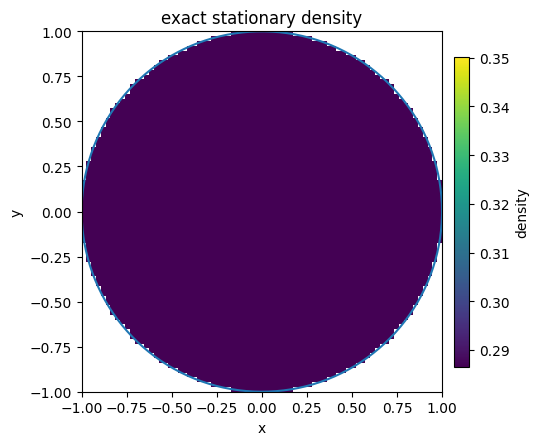

In [6]:
p_exact, x_edges, y_edges = exact_disk_density_cartesian(radius, bins, b, sigma)

colorbar_values = get_colorbar_values_2d([p_exact])

fig, ax = plt.subplots(figsize=(5, 5))

plot_density_disk(p_exact, x_edges, y_edges, radius=radius, ax=ax, title="exact stationary density"
                  , colorbar_values=colorbar_values, cmap=cmap)

add_shared_colorbar(fig, ax, colorbar_values, cmap=cmap, label="density", fraction=0.04, pad=0.03)

plt.show()

### Numerical density in the full disk

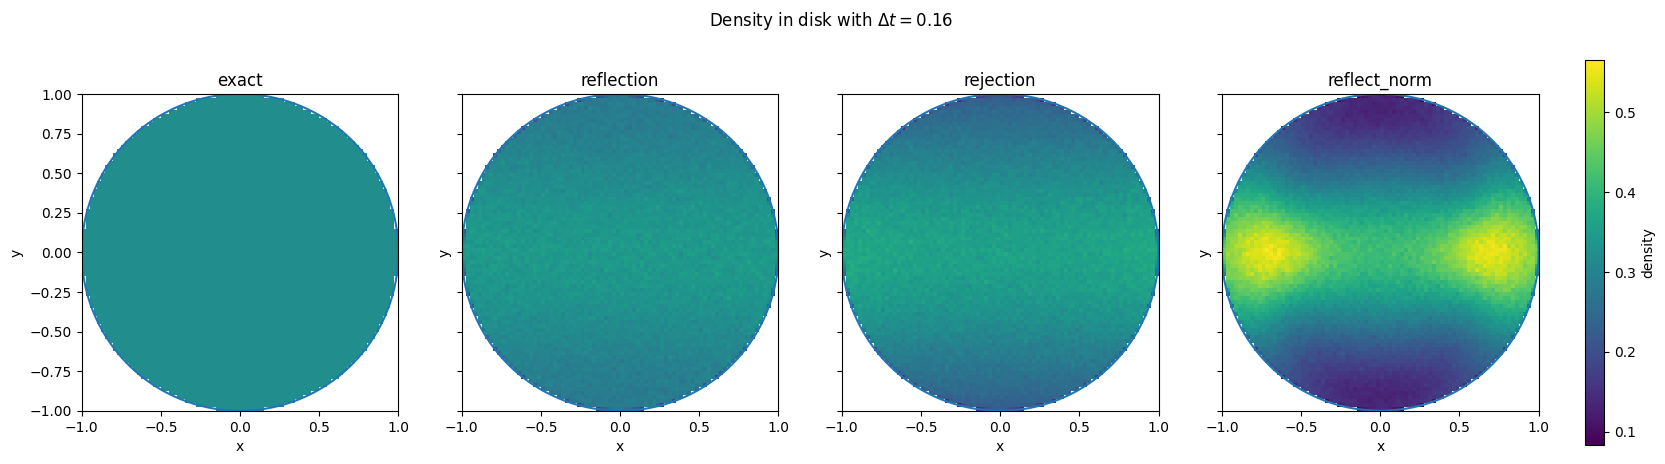

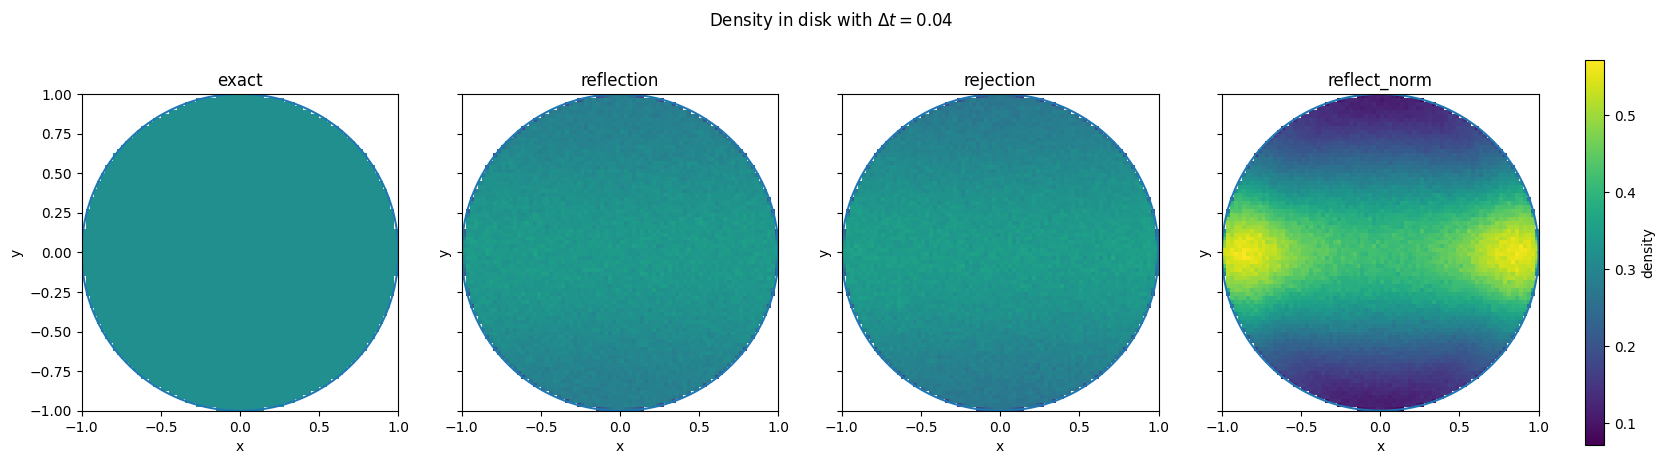

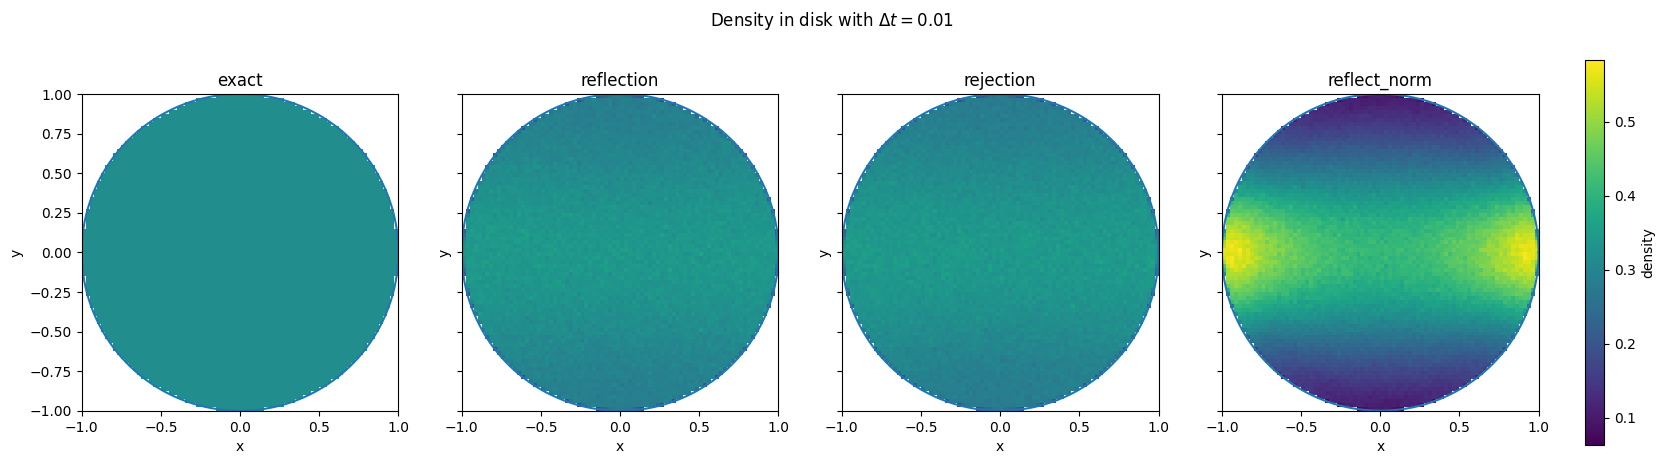

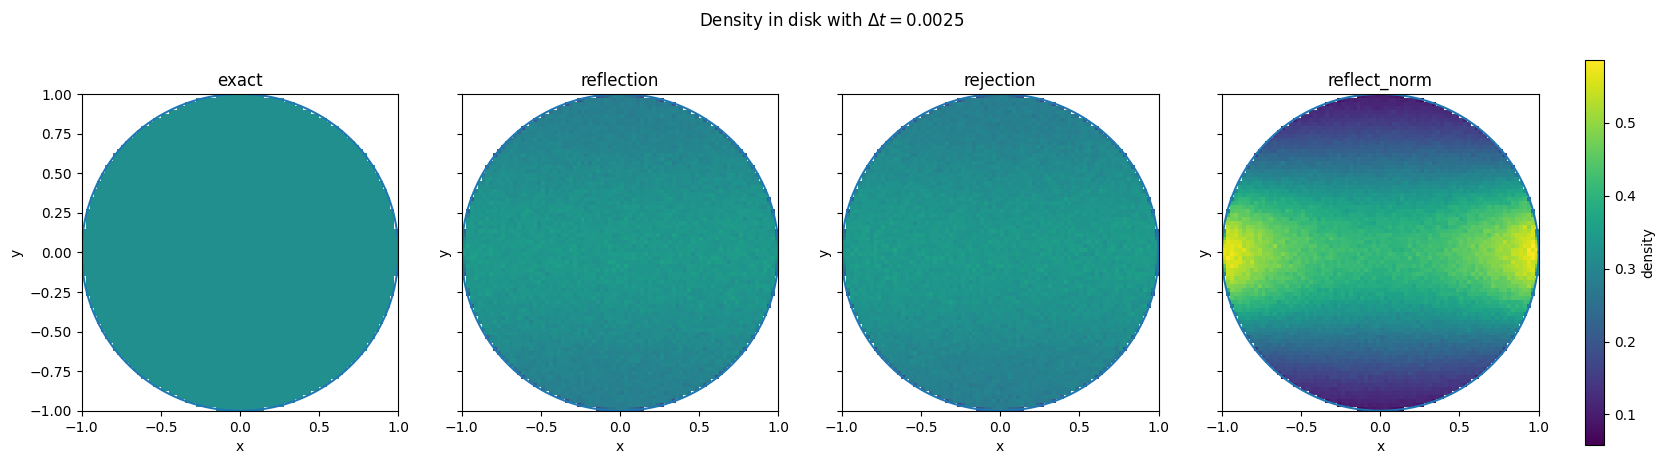

In [7]:
bins = 80

for dt in dt_list:

    p_exact, x_edges, y_edges = exact_disk_density_cartesian(radius, bins, b, sigma)

    density_data = {"exact": p_exact}
    p_scales = [p_exact]

    for boundary_type in boundary_types:
        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)
        p_num, x_edges, y_edges = histogram_density_disk(X, radius=radius, bins=bins)

        density_data[boundary_type] = p_num
        p_scales.append(p_num)

    colorbar_values = get_colorbar_values_2d(p_scales)

    fig, ax = plt.subplots(1, len(boundary_types) + 1, figsize=(5*(len(boundary_types) + 1), 5)
                           , sharex=True, sharey=True)

    ax = np.atleast_1d(ax)

    fig.suptitle(fr"Density in disk with $\Delta t={dt}$")

    plot_density_disk(density_data["exact"], x_edges, y_edges, radius=radius, ax=ax[0]
                      , title="exact", colorbar_values=colorbar_values, cmap=cmap )

    for i, boundary_type in enumerate(boundary_types):

        plot_density_disk( density_data[boundary_type], x_edges, y_edges, radius=radius, ax=ax[i + 1]
                          , title=boundary_type, colorbar_values=colorbar_values, cmap=cmap )

    add_shared_colorbar(fig, ax, colorbar_values, cmap=cmap, label="density")

    plt.show()

### Full-disk radial density slices

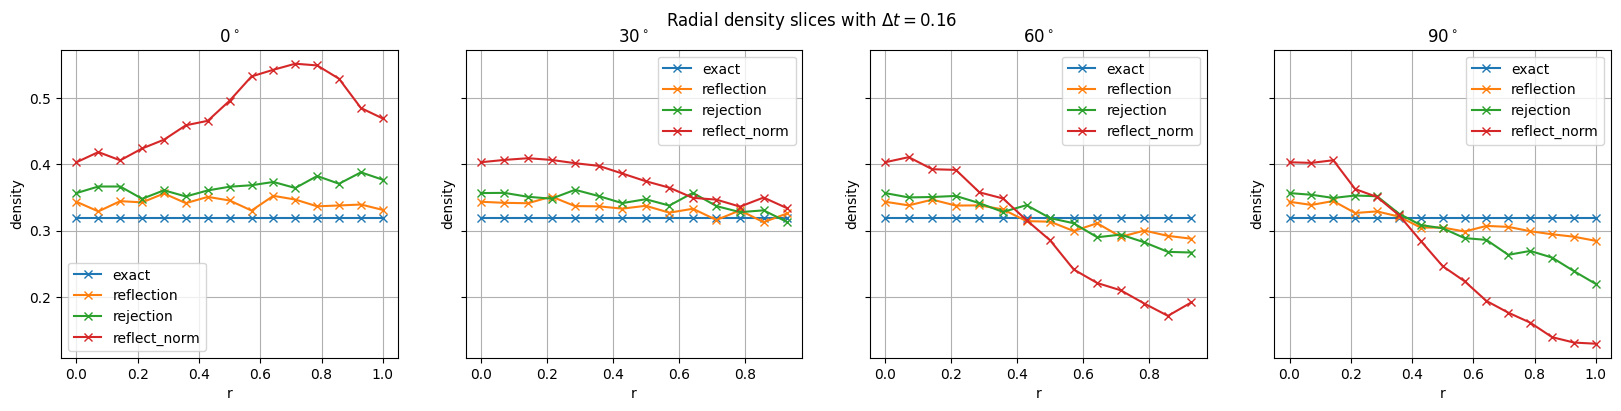

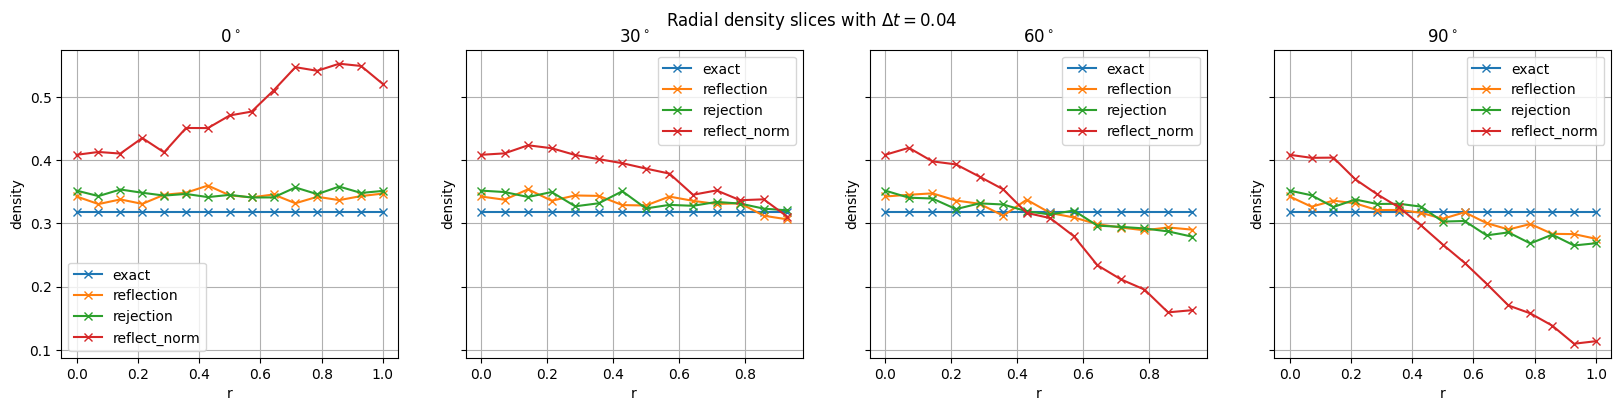

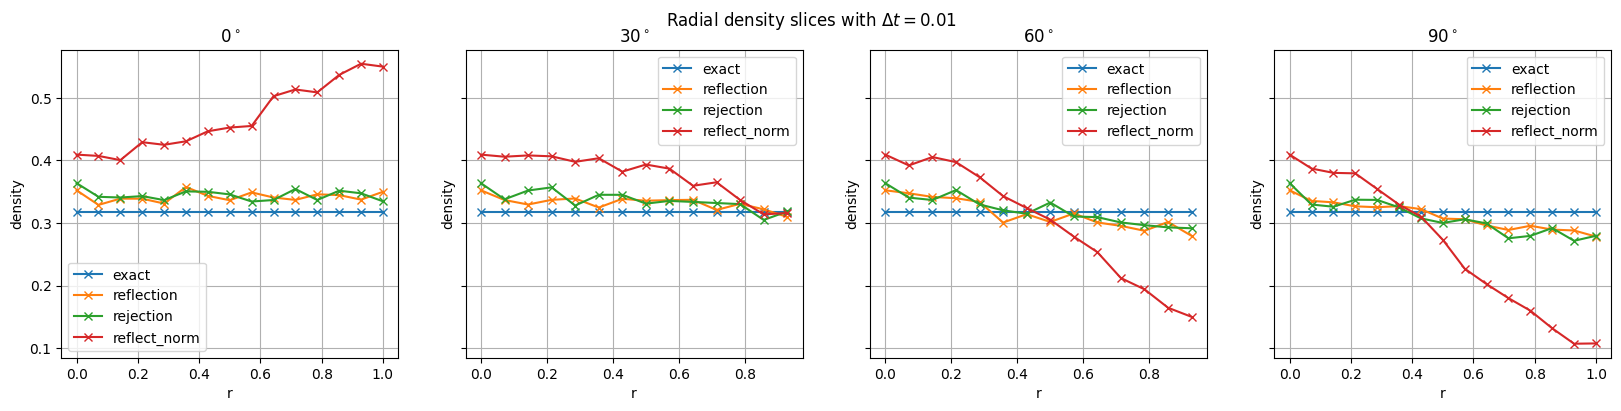

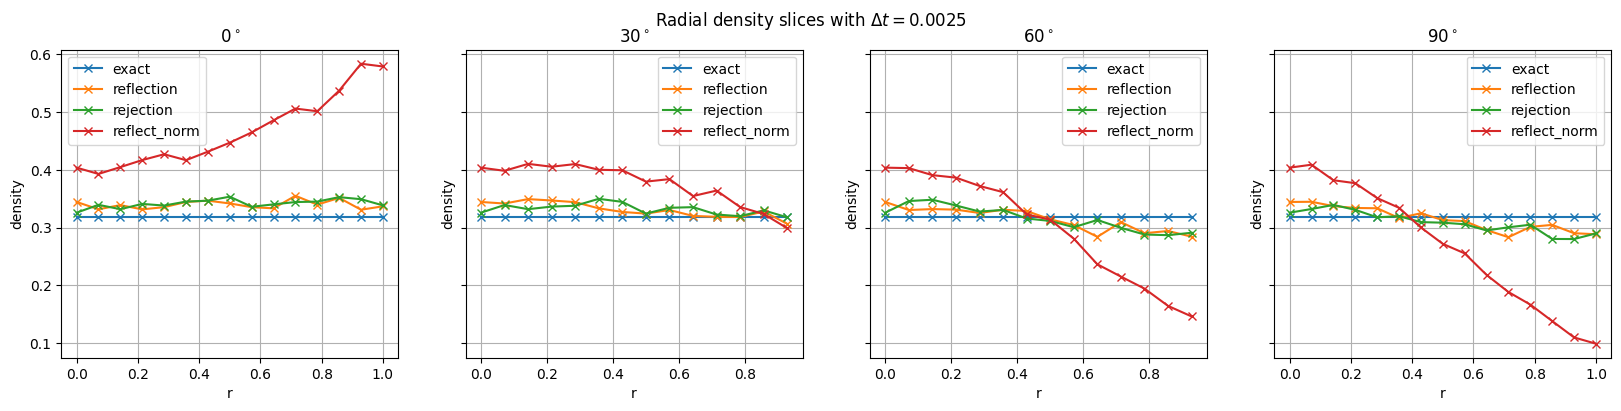

In [8]:
bins = 80
r_bins = 15

for dt in dt_list:

    p_exact, x_edges, y_edges = exact_disk_density_cartesian(radius, bins, b, sigma)

    density_data = {"exact": p_exact}

    for boundary_type in boundary_types:
        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)
        p_num, _, _ = histogram_density_disk(X, radius=radius, bins=bins)

        density_data[boundary_type] = p_num

    fig, ax = plt.subplots(1, len(angles), figsize=(5*len(angles), 4), sharey=True)
    ax = np.atleast_1d(ax)

    fig.suptitle(fr"Radial density slices with $\Delta t={dt}$")

    for j, theta_0 in enumerate(angles):

        r, values = field_disk_radial_slice( density_data["exact"], x_edges, y_edges, theta_0=theta_0
                                            , radius=radius, r_bins=r_bins )

        plot_radial_slice( r, values, ax=ax[j], title=angle_labels[j], label="exact", y_label="density" )

        for boundary_type in boundary_types:

            r, values = field_disk_radial_slice( density_data[boundary_type], x_edges, y_edges
                                                , theta_0=theta_0, radius=radius, r_bins=r_bins )

            plot_radial_slice( r, values, ax=ax[j], label=boundary_type, y_label="density" )

    plt.show()

### Full-domain absolute local error

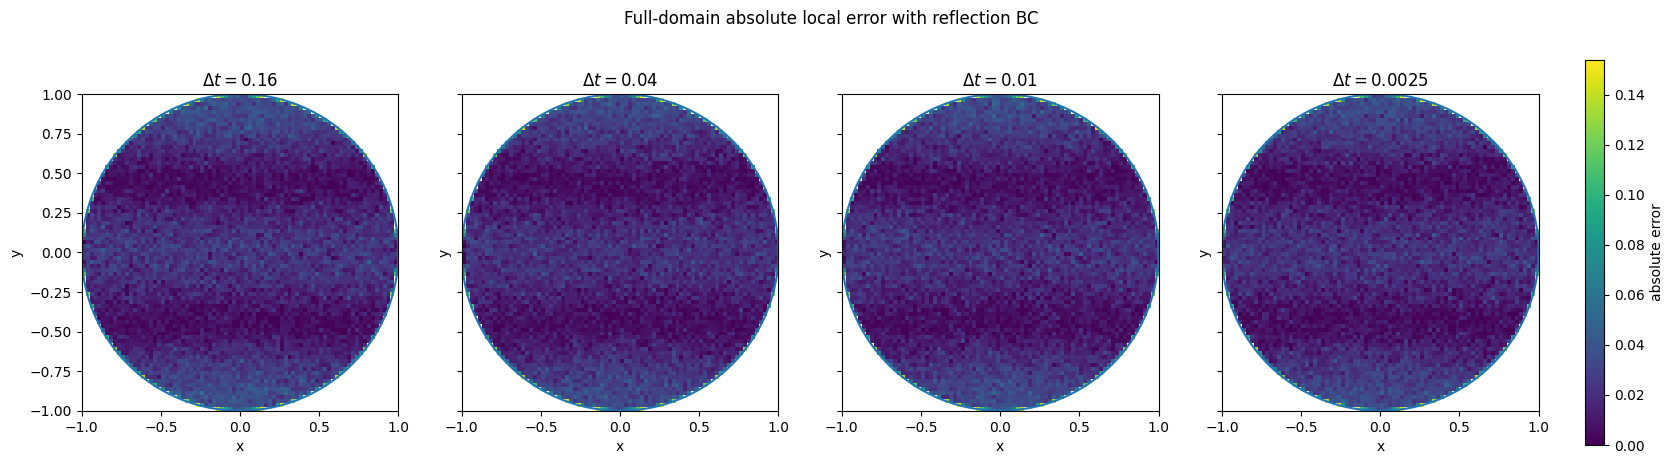

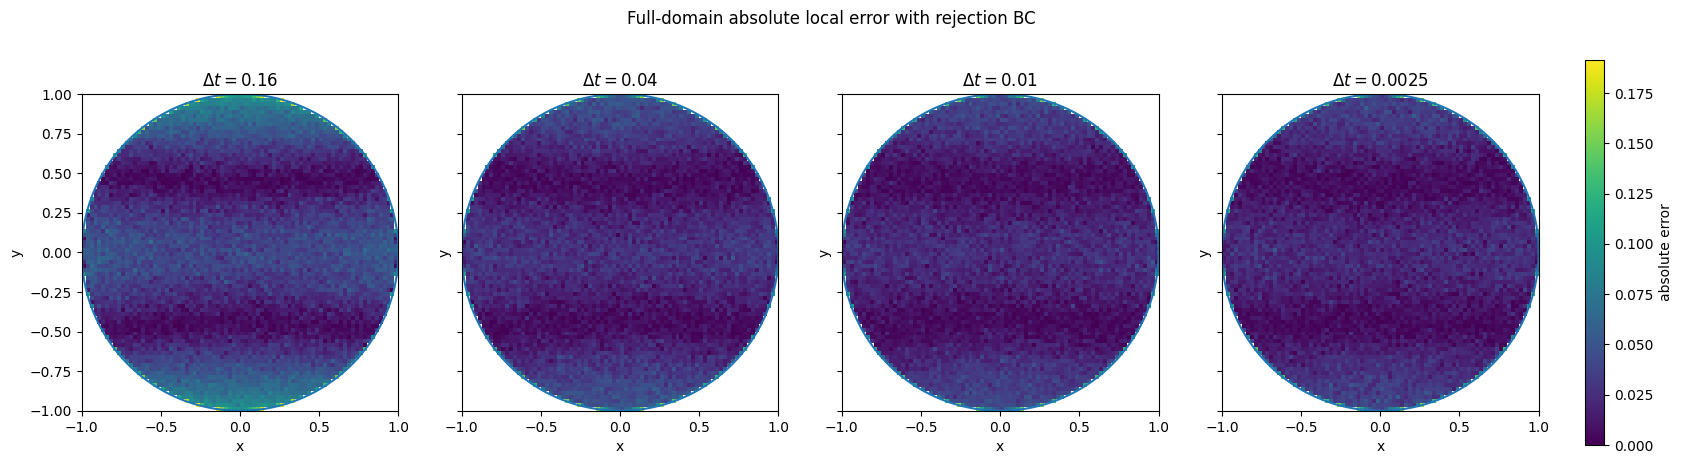

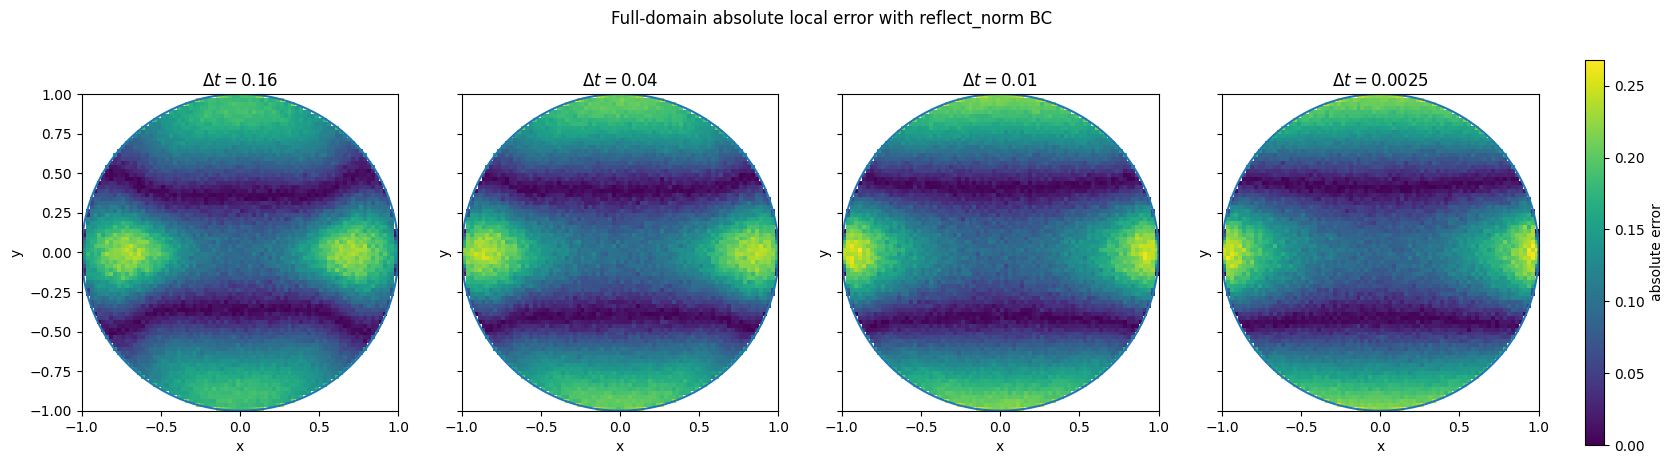

,boundary_type,dt,epsilon,L1_error,L2_error,relative_error
0,reflection,0.1600,0.40,0.060760,0.043758,0.077552
1,reflection,0.0400,0.20,0.056344,0.041340,0.073266
2,reflection,0.0100,0.10,0.056925,0.041527,0.073597
3,reflection,0.0025,0.05,0.056893,0.041539,0.073619
4,rejection,0.1600,0.40,0.107420,0.073257,0.129831
5,rejection,0.0400,0.20,0.070735,0.049665,0.088020
6,rejection,0.0100,0.10,0.062626,0.044697,0.079216
7,rejection,0.0025,0.05,0.059607,0.043162,0.076495
8,reflect_norm,0.1600,0.40,0.313801,0.205256,0.363771
9,reflect_norm,0.0400,0.20,0.319646,0.210162,0.372466


In [9]:
bins = 80

full_error_rows = []

for boundary_type in boundary_types:

    plot_data = []
    vmax = 0

    for dt in dt_list:

        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)

        p_num, x_edges, y_edges = histogram_density_disk(X, radius=radius, bins=bins)

        x_mesh, y_mesh = disk_cartesian_centres_mesh(x_edges, y_edges)
        p_true = stationary_solution_disk(x_mesh, y_mesh, b, sigma, radius=radius)

        error = local_error_density(p_num, p_true)
        abs_error = np.abs(error)

        L1_error, L2_error, relative_error = density_error_norms_cartesian(error, p_true, x_edges, y_edges)

        full_error_rows.append({"boundary_type":boundary_type, "dt":dt, "epsilon":np.sqrt(dt)
                                ,"L1_error":L1_error, "L2_error":L2_error, "relative_error":relative_error})

        vmax = max(vmax, np.nanmax(abs_error))

        plot_data.append((dt, abs_error, x_edges, y_edges))

    colorbar_values = (0, vmax)

    fig, ax = plt.subplots( 1, len(dt_list), figsize=(5*len(dt_list), 5), sharex=True, sharey=True )

    ax = np.atleast_1d(ax)

    fig.suptitle(f"Full-domain absolute local error with {boundary_type} BC")

    for i, (dt, abs_error, x_edges, y_edges) in enumerate(plot_data):

        plot_density_disk( abs_error, x_edges, y_edges, radius=radius, ax=ax[i], title=fr"$\Delta t={dt}$"
                          , colorbar_values=colorbar_values, cmap=cmap )

    add_shared_colorbar(fig, ax, colorbar_values, cmap=cmap, label="absolute error")

    plt.show()

full_error_table = pd.DataFrame(full_error_rows)
display(full_error_table)

### Full-domain absolute error radial slices

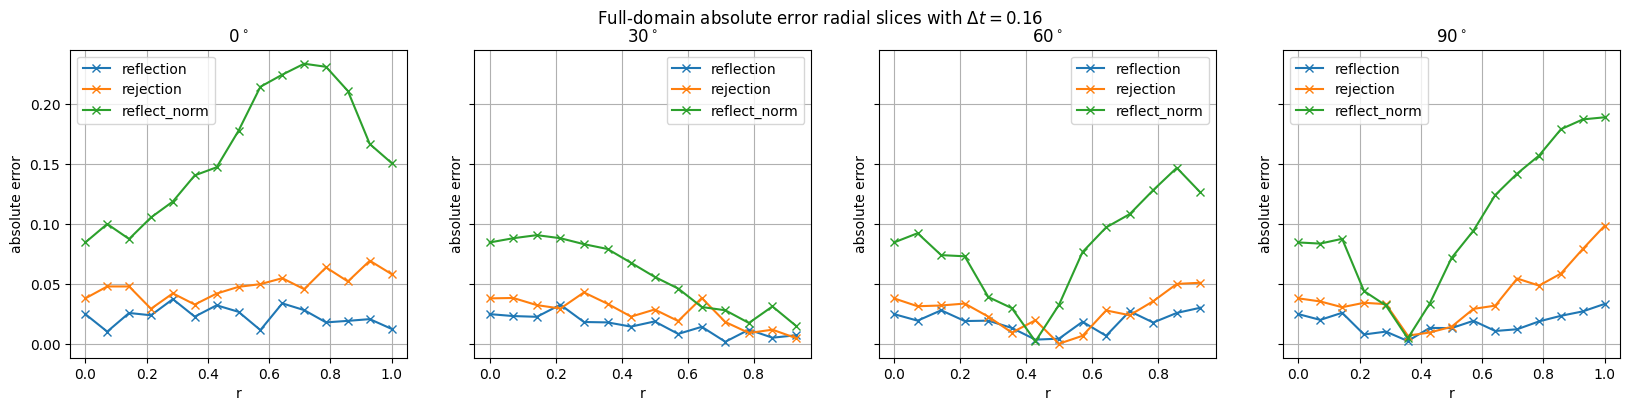

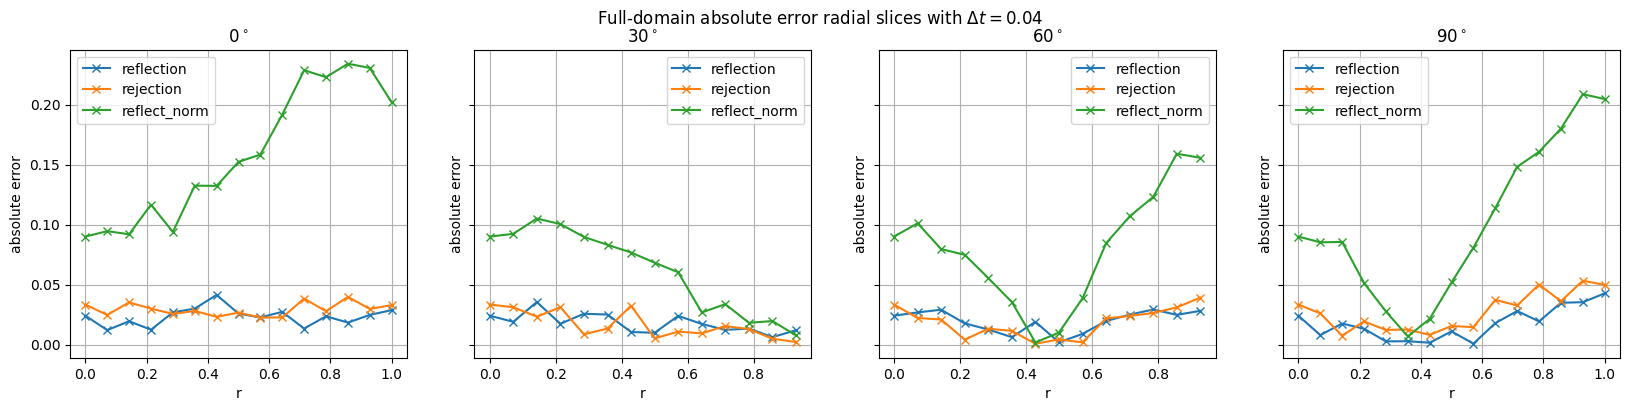

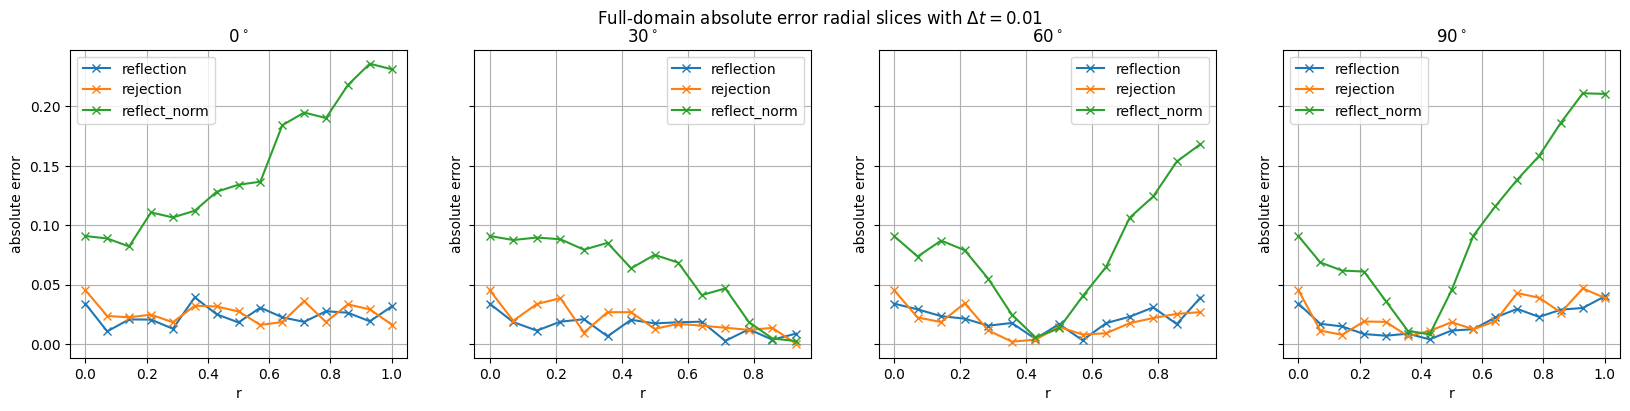

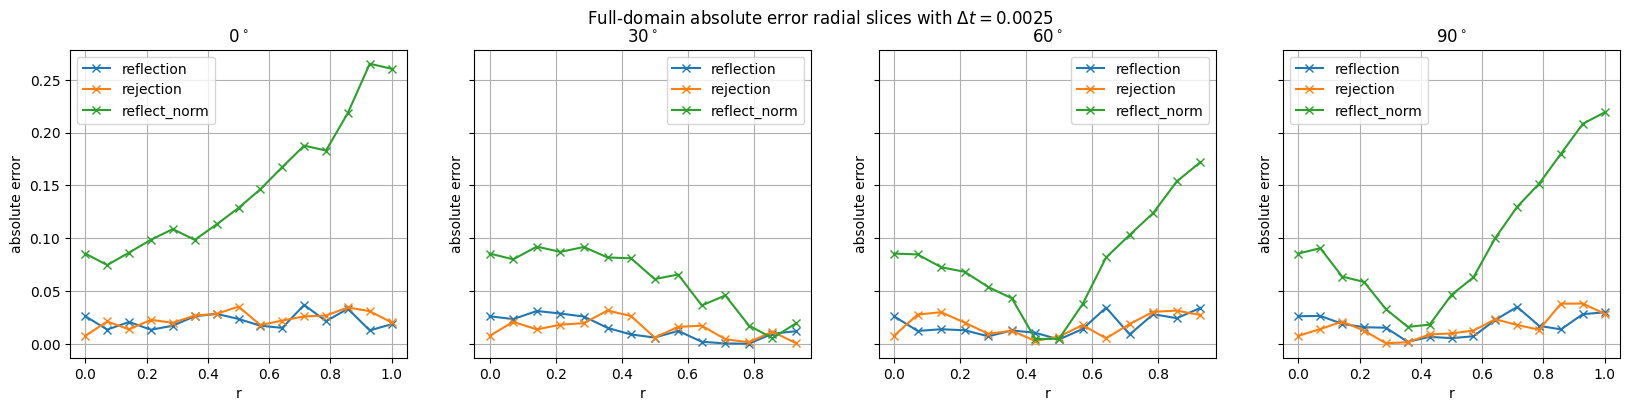

In [10]:
bins = 80
r_bins = 15
for dt in dt_list:

    error_data = {}

    for boundary_type in boundary_types:

        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)

        p_num, x_edges, y_edges = histogram_density_disk(X, radius=radius, bins=bins)

        x_mesh, y_mesh = disk_cartesian_centres_mesh(x_edges, y_edges)
        p_true = stationary_solution_disk(x_mesh, y_mesh, b, sigma, radius=radius)

        error_data[boundary_type] = np.abs(local_error_density(p_num, p_true))

    fig, ax = plt.subplots(1, len(angles), figsize=(5*len(angles), 4), sharey=True)
    ax = np.atleast_1d(ax)

    fig.suptitle(fr"Full-domain absolute error radial slices with $\Delta t={dt}$")

    for j, theta_0 in enumerate(angles):

        for boundary_type in boundary_types:

            r, values = field_disk_radial_slice( error_data[boundary_type], x_edges, y_edges
                                                , theta_0=theta_0, radius=radius, r_bins=r_bins )

            plot_radial_slice( r, values, ax=ax[j], title=angle_labels[j], label=boundary_type
                              , y_label="absolute error" )

    plt.show()

### Full-domain convergence

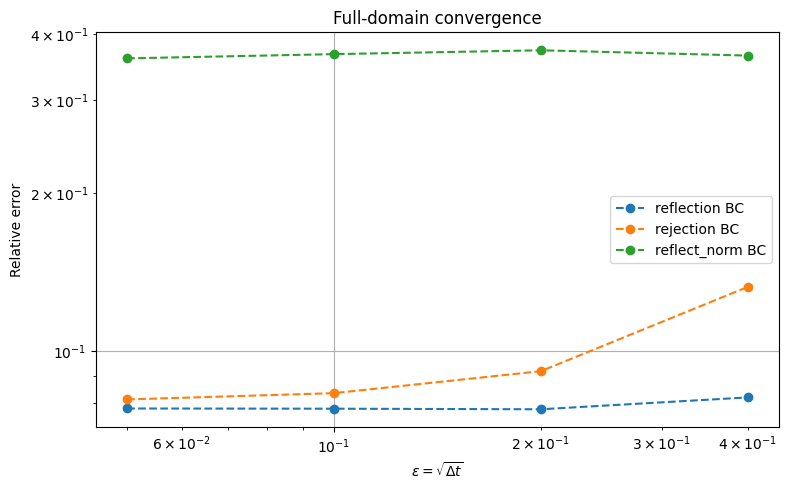

,boundary_type,observed_order_full
0,reflection,0.020577
1,rejection,0.226632
2,reflect_norm,0.007707


In [11]:
bins = 75
r_bins = 15

full_error_rows = []

for boundary_type in boundary_types:

    for dt in dt_list:

        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)

        p_num, x_edges, y_edges = histogram_density_disk(X, radius=radius, bins=bins)

        x_mesh, y_mesh = disk_cartesian_centres_mesh(x_edges, y_edges)
        p_true = stationary_solution_disk(x_mesh, y_mesh, b, sigma, radius=radius)

        error = local_error_density(p_num, p_true)

        L1_error, L2_error, relative_error = density_error_norms_cartesian(error, p_true, x_edges, y_edges)

        full_error_rows.append({"boundary_type":boundary_type, "dt":dt, "epsilon":np.sqrt(dt)
                                , "L1_error": L1_error, "L2_error": L2_error
                                , "relative_error": relative_error })

full_error_table = pd.DataFrame(full_error_rows)

plt.figure(figsize=(8, 5))

full_order_rows = []

for boundary_type in boundary_types:

    rows = full_error_table[full_error_table["boundary_type"] == boundary_type].sort_values("epsilon")

    epsilon_values = rows["epsilon"].to_numpy()
    errors = rows["relative_error"].to_numpy()

    plt.loglog(epsilon_values, errors, marker="o", linestyle="--", label=f"{boundary_type} BC")

    order = np.polyfit(np.log(epsilon_values), np.log(errors), 1)[0]
    full_order_rows.append({"boundary_type": boundary_type, "observed_order_full": order})

plt.xlabel(r"$\varepsilon=\sqrt{\Delta t}$")
plt.ylabel(r"Relative error")
plt.title("Full-domain convergence")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

full_convergence_table = pd.DataFrame(full_order_rows)
display(full_convergence_table)

## Boundary analysis

### Numerical density near the boundary

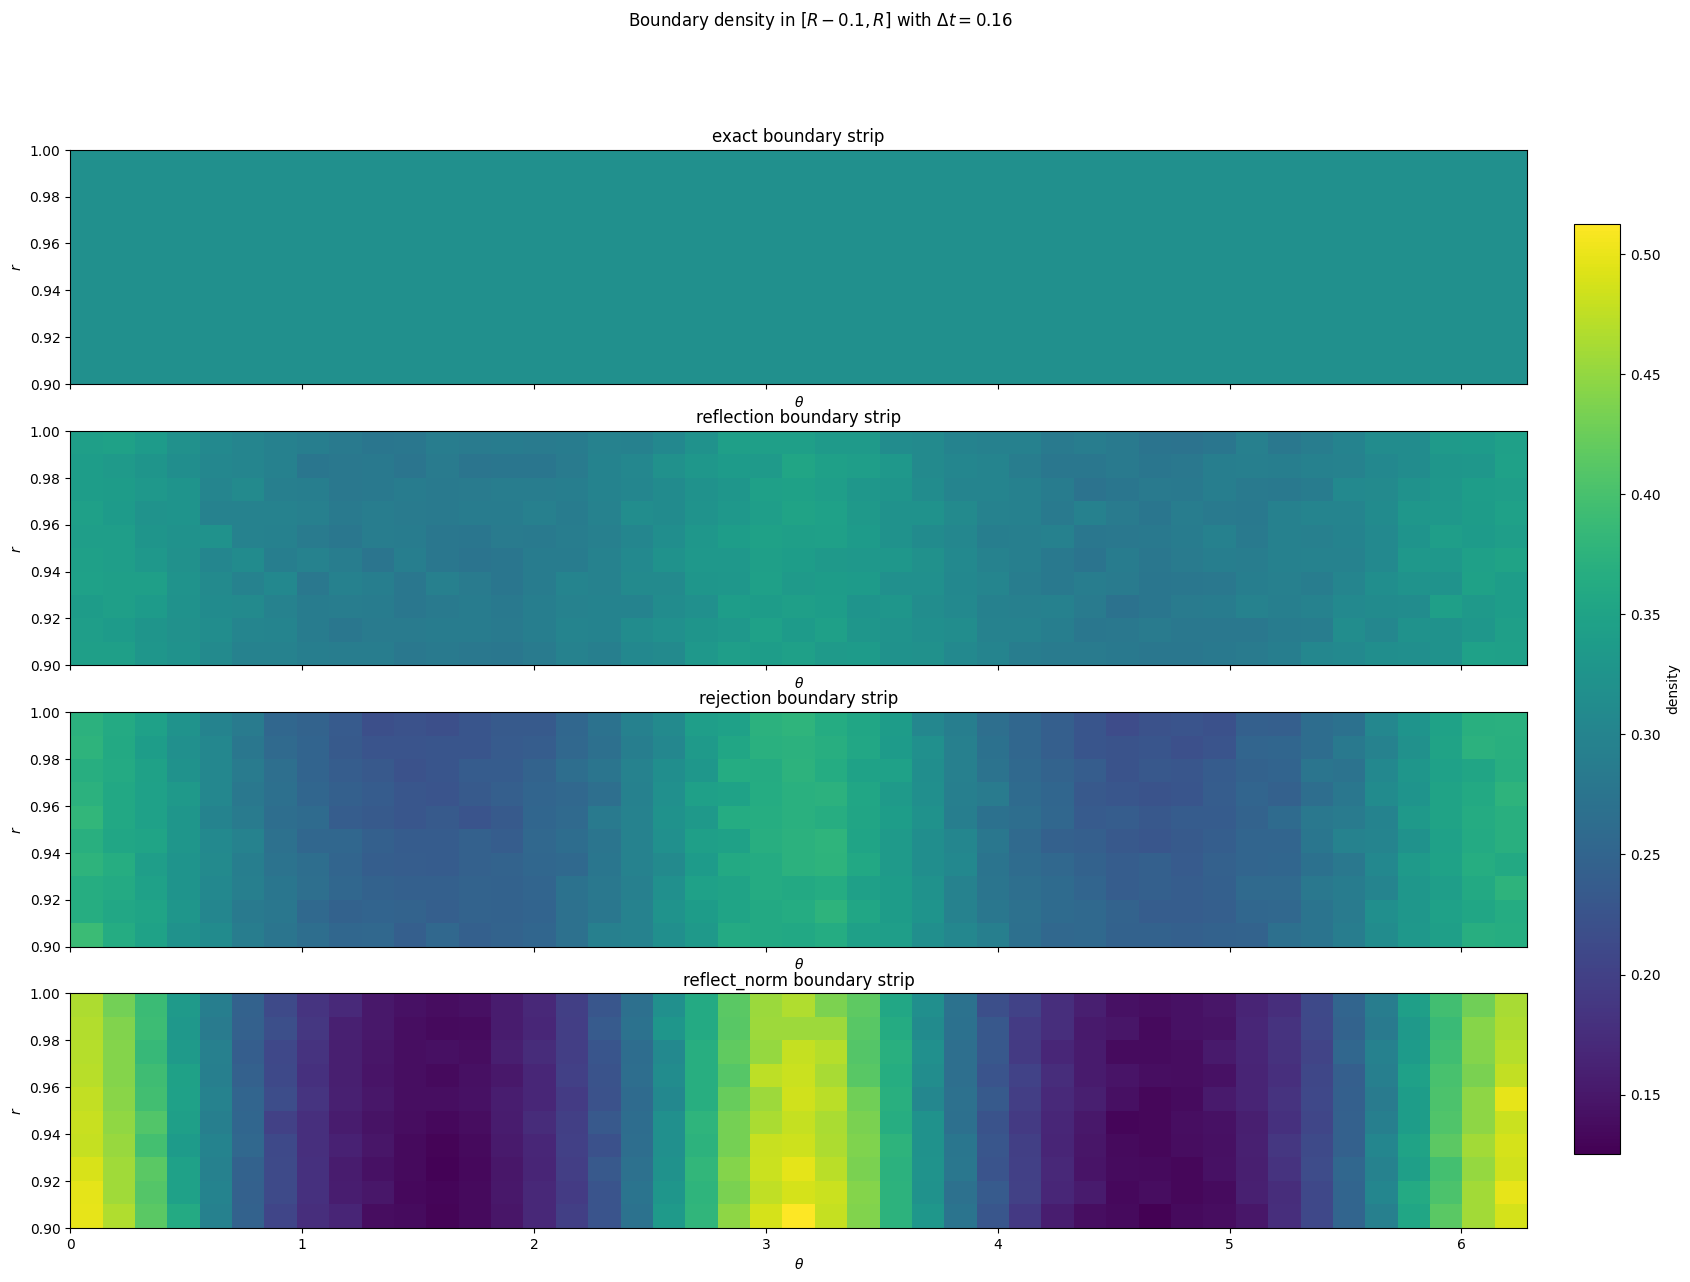

In [ ]:
bins = 80
r_bins = 10
theta_bins = 45

for dt in dt_list:

    r_range = (radius - boundary_width, radius)

    theta_edges = np.linspace(0, 2*np.pi, theta_bins + 1)
    r_edges = np.linspace(r_range[0], r_range[1], r_bins + 1)

    p_true = exact_disk_density_polar(theta_edges, r_edges, b, sigma, radius)

    density_data = {"exact": p_true}
    p_scales = [p_true]

    for boundary_type in boundary_types:
        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)

        p_num, theta_edges, r_edges, counts = density_disk_range( X, r_range=r_range
                                                                 , theta_bins=theta_bins, r_bins=r_bins)

        density_data[boundary_type] = p_num
        p_scales.append(p_num)

    colorbar_values = get_colorbar_values_2d(p_scales)

    fig, ax = plt.subplots( len(boundary_types) +1, 1, figsize=(20, 14), sharex=True, sharey=True )

    ax = np.atleast_1d(ax)

    fig.suptitle(fr"Boundary density in $[R-{boundary_width}, R]$ with $\Delta t={dt}$")

    plot_density_disk_range( density_data["exact"], theta_edges, r_edges, ax=ax[0]
                            , title="exact boundary strip", colorbar_values=colorbar_values, cmap=cmap)

    for i, boundary_type in enumerate(boundary_types):

        plot_density_disk_range( density_data[boundary_type], theta_edges, r_edges, ax=ax[i + 1]
                                , title=f"{boundary_type} boundary strip", colorbar_values=colorbar_values
                                , cmap=cmap )

    add_shared_colorbar(fig, ax, colorbar_values, cmap=cmap, label="density")

    plt.show()

### Boundary-strip absolute local error

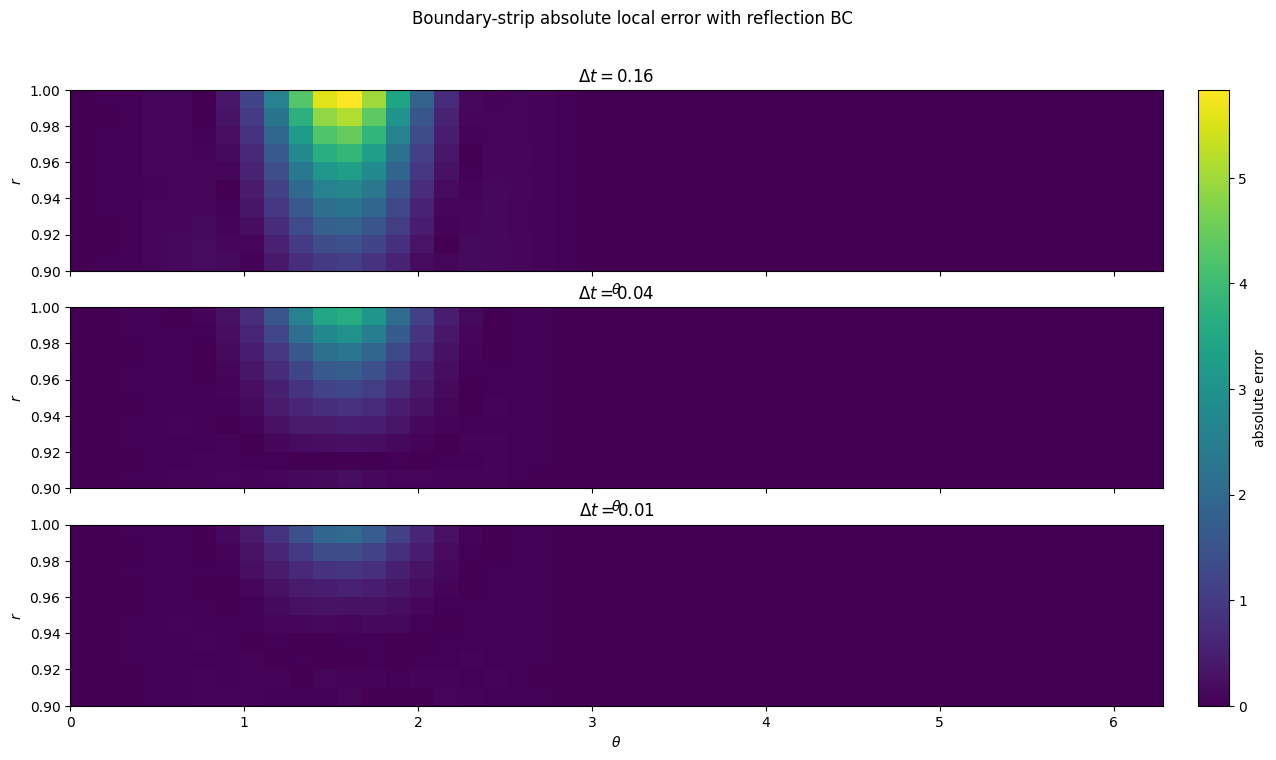

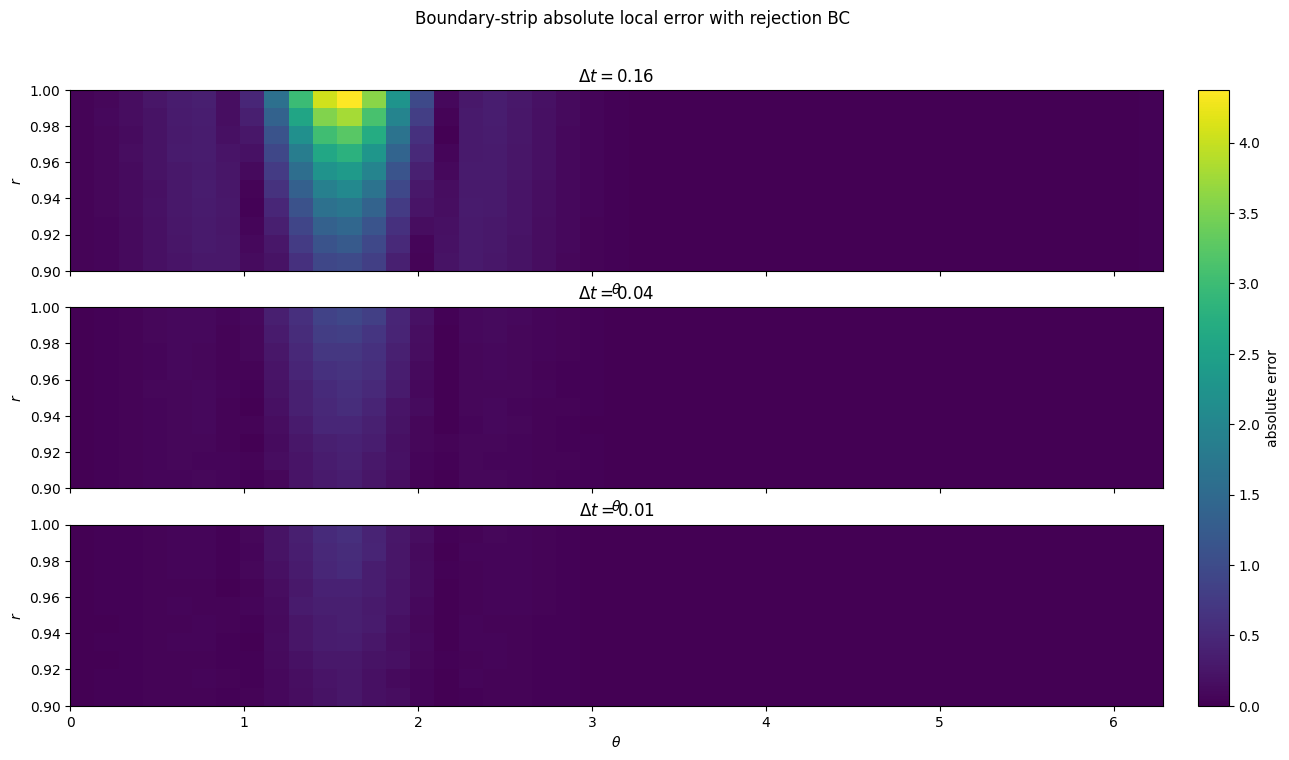

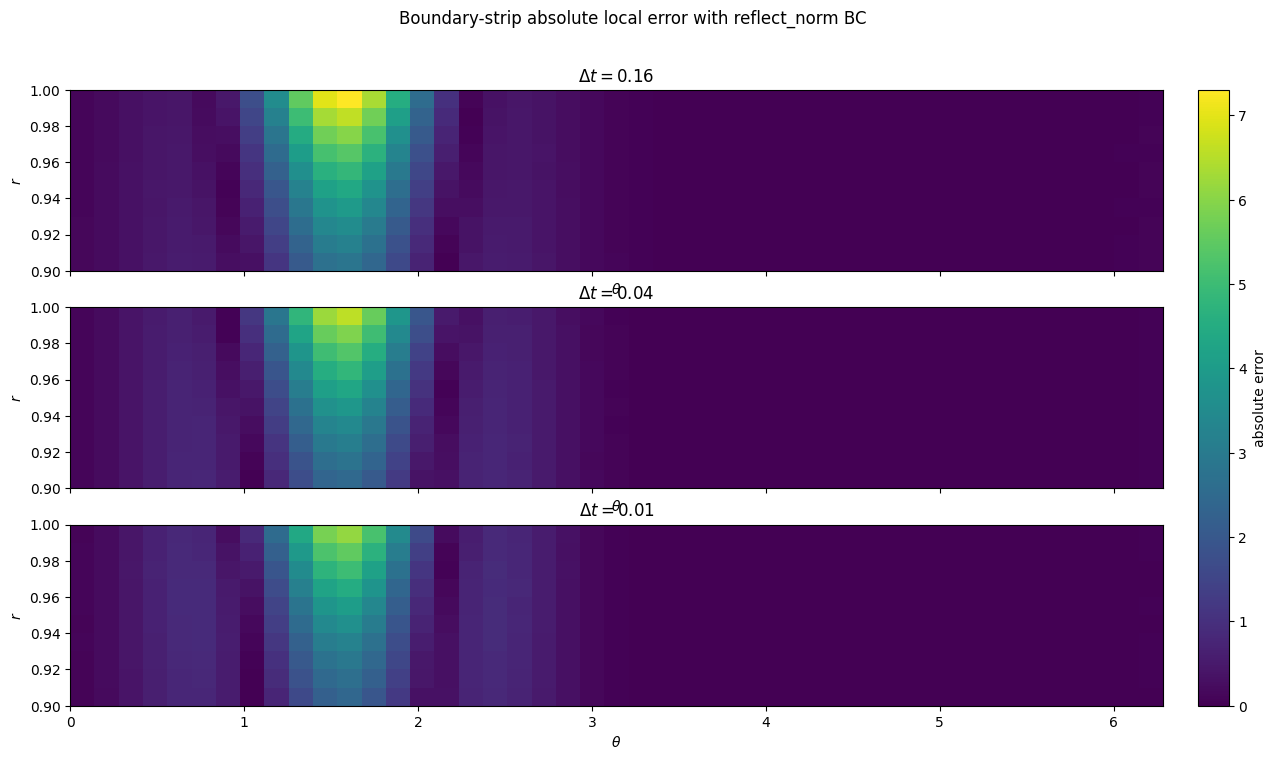

,boundary_type,dt,epsilon,r_width,L1_error,L2_error,relative_error
0,reflection,0.16,0.4,0.1,0.228348,0.803491,0.480747
1,reflection,0.04,0.2,0.1,0.099873,0.408009,0.244121
2,reflection,0.01,0.1,0.1,0.043635,0.193325,0.115671
3,rejection,0.16,0.4,0.1,0.179563,0.572264,0.342399
4,rejection,0.04,0.2,0.1,0.045592,0.134518,0.080485
5,rejection,0.01,0.1,0.1,0.030790,0.088484,0.052942
6,reflect_norm,0.16,0.4,0.1,0.392566,1.166572,0.697987
7,reflect_norm,0.04,0.2,0.1,0.357140,1.017423,0.608748
8,reflect_norm,0.01,0.1,0.1,0.345881,0.952421,0.569856


In [ ]:
boundary_error_rows = []

for boundary_type in boundary_types:

    plot_data = []
    vmax = 0

    for dt in dt_list:

        epsilon = np.sqrt(dt)
        r_range = (radius - boundary_width, radius)

        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)

        p_num, theta_edges, r_edges, counts = density_disk_range( X, r_range=r_range
                                                                 , theta_bins=theta_bins, r_bins=r_bins )

        p_true = exact_disk_density_polar(theta_edges, r_edges, b, sigma, radius)

        error = local_error_density(p_num, p_true)
        abs_error = np.abs(error)

        L1_error, L2_error, relative_error = density_error_norms(error, p_true, theta_edges, r_edges)

        boundary_error_rows.append({ "boundary_type": boundary_type, "dt": dt, "epsilon": epsilon
                                    , "r_width": boundary_width, "L1_error": L1_error, "L2_error": L2_error
                                    , "relative_error": relative_error })

        vmax = max(vmax, np.nanmax(abs_error))

        plot_data.append((dt, abs_error, theta_edges, r_edges))

    colorbar_values = (0, vmax)

    fig, ax = plt.subplots( len(dt_list), 1, figsize=(15, 8), sharex=True, sharey=True )

    ax = np.atleast_1d(ax)

    fig.suptitle(f"Boundary-strip absolute local error with {boundary_type} BC")

    for i, (dt, abs_error, theta_edges, r_edges) in enumerate(plot_data):

        plot_density_disk_range( abs_error, theta_edges, r_edges, ax=ax[i], title=fr"$\Delta t={dt}$"
                                , colorbar_values=colorbar_values, cmap=cmap )

    add_shared_colorbar(fig, ax, colorbar_values, cmap=cmap, label="absolute error")

    plt.show()

boundary_error_table = pd.DataFrame(boundary_error_rows)
display(boundary_error_table)

### Boundary-strip convergence

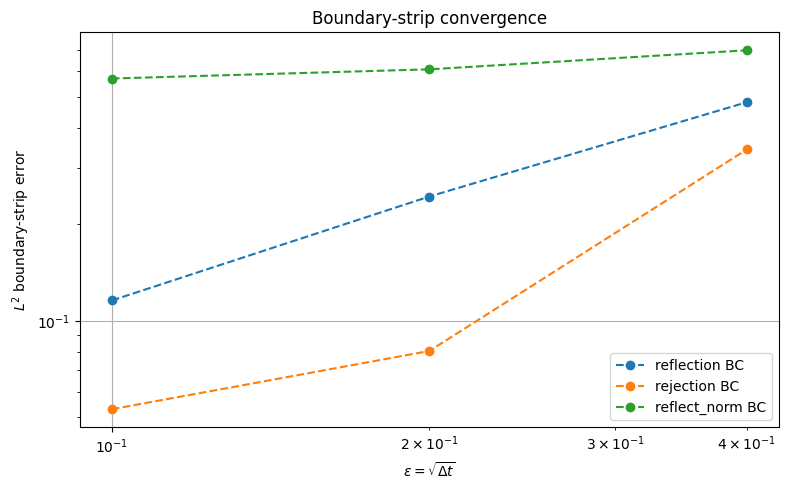

,boundary_type,observed_order_boundary
0,reflection,1.027627
1,rejection,1.346596
2,reflect_norm,0.146302


In [ ]:
boundary_error_rows = []

for boundary_type in boundary_types:

    for dt in dt_list:

        epsilon = np.sqrt(dt)
        r_range = (radius - boundary_width, radius)

        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)

        p_num, theta_edges, r_edges, counts = density_disk_range( X, r_range=r_range, theta_bins=theta_bins
                                                                 , r_bins=r_bins )

        p_true = exact_disk_density_polar(theta_edges, r_edges, b, sigma, radius)

        error = local_error_density(p_num, p_true)

        L1_error, L2_error, relative_error = density_error_norms(error, p_true, theta_edges, r_edges)

        boundary_error_rows.append({ "boundary_type": boundary_type, "dt": dt, "epsilon": epsilon
                                    , "r_width": boundary_width, "L1_error": L1_error, "L2_error": L2_error
                                    , "relative_error" : relative_error })

boundary_error_table = pd.DataFrame(boundary_error_rows)

plt.figure(figsize=(8, 5))

boundary_order_rows = []

for boundary_type in boundary_types:

    rows = boundary_error_table[boundary_error_table["boundary_type"] == boundary_type].sort_values("epsilon")

    epsilon_values = rows["epsilon"].to_numpy()
    errors = rows["relative_error"].to_numpy()

    plt.loglog(epsilon_values, errors, marker="o", linestyle="--", label=f"{boundary_type} BC")

    order = np.polyfit(np.log(epsilon_values), np.log(errors), 1)[0]
    boundary_order_rows.append({"boundary_type": boundary_type, "observed_order_boundary": order})

plt.xlabel(r"$\varepsilon=\sqrt{\Delta t}$")
plt.ylabel(r"$L^2$ boundary-strip error")
plt.title("Boundary-strip convergence")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

boundary_convergence_table = pd.DataFrame(boundary_order_rows)
display(boundary_convergence_table)

### Stretched boundary-layer absolute error

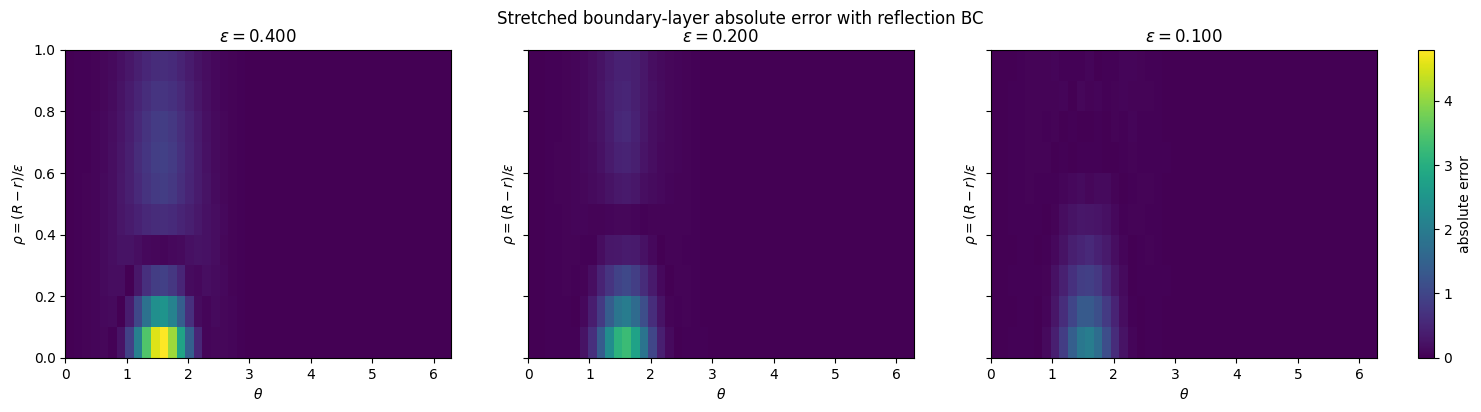

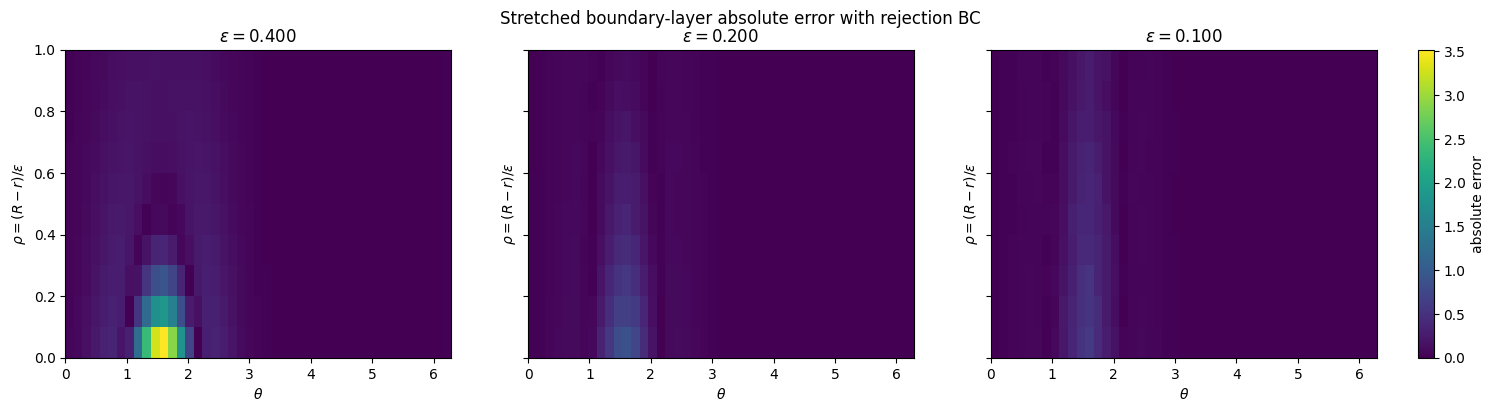

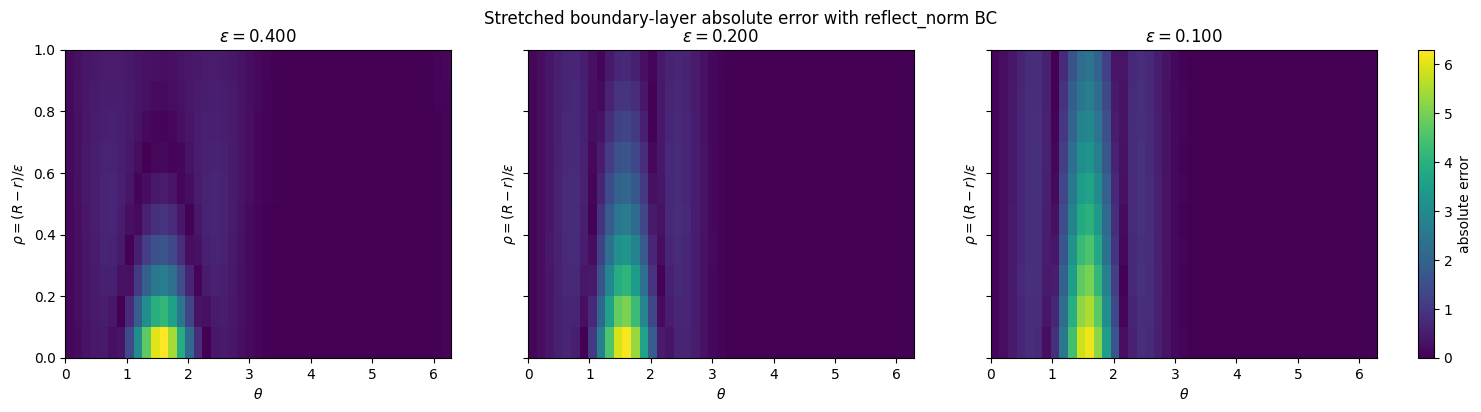

In [ ]:
for boundary_type in boundary_types:

    plot_data = []
    vmax = 0

    for dt in dt_list:

        epsilon = np.sqrt(dt)
        r_range = (radius - epsilon, radius)

        X = load_solution(f"{boundary_type}_dt-{dt}.npy", problem_path)

        p_num, theta_edges, r_edges, counts = density_disk_range( X, r_range=r_range, theta_bins=theta_bins
                                                                 , r_bins=r_bins )

        p_true = exact_disk_density_polar(theta_edges, r_edges, b, sigma, radius)

        error = local_error_density(p_num, p_true)
        abs_error = np.abs(error)

        rho_edges = (radius - r_edges)/epsilon

        vmax = max(vmax, np.nanmax(abs_error))

        plot_data.append((dt, epsilon, abs_error, theta_edges, rho_edges))

    colorbar_values = (0, vmax)

    fig, ax = plt.subplots( 1, len(dt_list), figsize=(6*len(dt_list), 4), sharex=True, sharey=True )

    ax = np.atleast_1d(ax)

    fig.suptitle(f"Stretched boundary-layer absolute error with {boundary_type} BC")

    for i, (dt, epsilon, abs_error, theta_edges, rho_edges) in enumerate(plot_data):

        plot_density_mesh(abs_error, theta_edges, rho_edges, ax=ax[i], title=fr"$\varepsilon={epsilon:.3f}$"
                          , colorbar_values=colorbar_values, cmap=cmap, x_label=r"$\theta$"
                          , y_label=r"$\rho=(R-r)/\varepsilon$", equal_aspect=False )

        ax[i].set_ylim(rho_edges[-1], rho_edges[0])

    add_shared_colorbar(fig, ax, colorbar_values, cmap=cmap, label="absolute error")

    plt.show()